# DALLE로 이미지 생성하기

Images API는 이미지와 상호작용하기 위한 세 가지 방법을 제공합니다.

1. 텍스트 프롬프트를 기반으로 처음부터 이미지 생성(DALL·E 3 및 DALL·E 2)
2. 새 텍스트 프롬프트를 기반으로 모델이 기존 이미지의 일부 영역을 대체하도록 하여 편집된 이미지 버전 생성(DALL·E 2에만 해당)
3. 기존 이미지의 변형 생성(DALL·E 2에만 해당)

DALL·E-2 모델의 경우 256x256, 512x512 또는 1024x1024 중 하나여야 합니다.   
DALL·E 3을 사용하는 경우 이미지 크기는 1024x1024, 1024x1792 또는 1792x1024 픽셀일 수 있습니다.   
기본적으로 이미지는 standard품질로 생성되지만 DALL·E 3을 사용하면 quality: "hd"향상된 세부 묘사를 설정할 수 있습니다. 정사각형의 표준 품질 이미지가 생성되는 속도가 가장 빠릅니다.

In [1]:
import os
import openai
import sys
sys.path.append('./')

from dotenv import load_dotenv, find_dotenv
_ = load_dotenv(find_dotenv()) # read local .env file

In [2]:
from openai import OpenAI
client = OpenAI()

In [3]:
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

# 주어진 URL의 이미지 시각화
def show_image_from_url(url):
    response = requests.get(url)                # 이미지 URL로 GET 요청을 보냄
    img = Image.open(BytesIO(response.content)) # 응답에서 바이트 코드로 된 이미지를 열기
    plt.imshow(img)                             # Matplotlib를 사용하여 이미지 표시
    plt.axis('off')                                # 이미지만 표시하기 위해 축을 숨김
    plt.show()                                  # 이미지를 화면에 표시

# 제공된 URL의 이미지를 저장하는 함수
def save_image_from_url(url, file_path):
    response = requests.get(url)                  # GET 요청
    if response.status_code == 200:            # 요청이 성공적이었는지 확인
        with open(file_path, 'wb') as f:            # 바이너리 쓰기 모드로 파일 열기
            f.write(response.content)                # 응답의 내용을 파일에 작성
        print(f"Image saved at {file_path}")     # 이미지가 저장된 경로 출력
    else:
        print(f"Error: Unable to retrieve image. Status code: {response.status_code}")  # 이미지 검색 실패 시 오류 메시지 출력

- 이미지 생성

In [4]:
response = client.images.generate(
  model="dall-e-3",
  prompt="a white siamese cat",
  size="1024x1024",
  quality="standard",   #‘standard’ or ‘hd’
  n=1,  #생성할 이미지 수 (1-10). dall-e-3의 경우 n=1만 지원
)

image_url = response.data[0].url

In [4]:
image_url

'https://oaidalleapiprodscus.blob.core.windows.net/private/org-vV0JFEecUSIx00tpFJyeNdmF/user-G2BphPbd4Y7h8zgKto1RrlhX/img-tyqeKQbAPCSuDoFIHqHSqmxm.png?st=2024-06-17T23%3A21%3A49Z&se=2024-06-18T01%3A21%3A49Z&sp=r&sv=2023-11-03&sr=b&rscd=inline&rsct=image/png&skoid=6aaadede-4fb3-4698-a8f6-684d7786b067&sktid=a48cca56-e6da-484e-a814-9c849652bcb3&skt=2024-06-17T19%3A38%3A55Z&ske=2024-06-18T19%3A38%3A55Z&sks=b&skv=2023-11-03&sig=F7JRa/xejXReSyy6UD3FKf3RyLpIzeudh45TQlSR5wQ%3D'

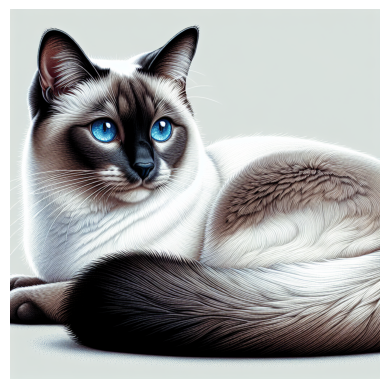

In [5]:
show_image_from_url(image_url)

In [6]:
save_image_from_url(image_url, "output/test_image.jpg")

Image saved at output/test_image.jpg


- Prompt Engineering 없이 이미지 생성

In [10]:
response = client.images.generate(
  model="dall-e-3",
  prompt="I NEED to test how the tool works with extremely simple prompts. DO NOT add any detail, just use it AS-IS: a white siamese cat",
  size="1024x1024",
  quality="standard",
  n=1,
)

image_url = response.data[0].url

In [11]:
image_url

'https://oaidalleapiprodscus.blob.core.windows.net/private/org-vV0JFEecUSIx00tpFJyeNdmF/user-G2BphPbd4Y7h8zgKto1RrlhX/img-U6t1bUrJ1CE6Pl4YnT98Mhdi.png?st=2024-07-08T05%3A28%3A46Z&se=2024-07-08T07%3A28%3A46Z&sp=r&sv=2023-11-03&sr=b&rscd=inline&rsct=image/png&skoid=6aaadede-4fb3-4698-a8f6-684d7786b067&sktid=a48cca56-e6da-484e-a814-9c849652bcb3&skt=2024-07-07T08%3A36%3A06Z&ske=2024-07-08T08%3A36%3A06Z&sks=b&skv=2023-11-03&sig=SziNL27Fyfgy3uDdsjn/sFCS0FfZO2GS6j0u%2BCfqScI%3D'

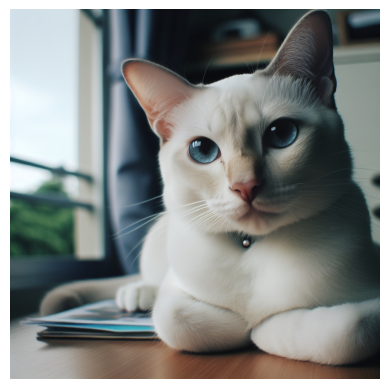

In [9]:
show_image_from_url(image_url)

- 고품질 이미지 생성

In [15]:
response = client.images.generate(
  model="dall-e-3",
  prompt="a white siamese cat",
  size="1024x1024",
  quality="hd",  #향상된 이미지 품질
  n=1,
  style="natural"   #default: vivid
)

image_url = response.data[0].url

In [16]:
image_url

'https://oaidalleapiprodscus.blob.core.windows.net/private/org-vV0JFEecUSIx00tpFJyeNdmF/user-G2BphPbd4Y7h8zgKto1RrlhX/img-XQ3vnnC1XnoJFZSpKeBmCiu9.png?st=2024-07-08T05%3A30%3A09Z&se=2024-07-08T07%3A30%3A09Z&sp=r&sv=2023-11-03&sr=b&rscd=inline&rsct=image/png&skoid=6aaadede-4fb3-4698-a8f6-684d7786b067&sktid=a48cca56-e6da-484e-a814-9c849652bcb3&skt=2024-07-08T02%3A53%3A08Z&ske=2024-07-09T02%3A53%3A08Z&sks=b&skv=2023-11-03&sig=KWhzQeJ/I7RI09AzITDxfRDcsJvzLfVwPYOtLQNw8h4%3D'

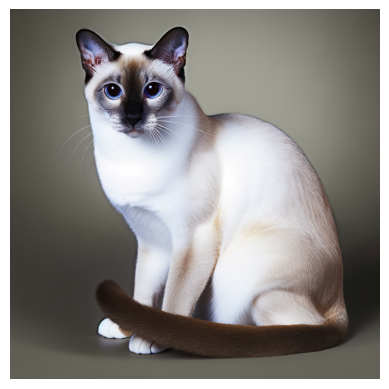

In [17]:
show_image_from_url(image_url)